In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
from matplotlib import gridspec as gridspec
from matplotlib.patches import Rectangle
# from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np

plt.style.use('seaborn-darkgrid')

## spike calling method
# use percentage based threshold of the data distribution instead of a global/local method, if on global/local will not be used! --- default: True
percentage_based_threshold = True
# percentage of data distribution for simple method --- default: 0.99 (min 0.00 - max 1.00)
percentage_threshold = 0.95
# global/local standard deviation (stddev) based on data, threshold can be set to n times the stddev --- default: 3 (recommended: multiplier not lower than 2.5)
global_standard_deviation_threshold_multiplier = 1
local_standard_deviation_threshold_multiplier = 3

## spike calling settings
# how many seconds to wait after a spike peak has been to defined before another spike can start to be defined
spike_offset_time = 5
# time offset in seconds to detect overlap in spikes from other video (as measurements are not on the exact same time scale) --- default: 0.2
nb_time_offset = 0.01

## plotting settings
# plot rectangles on traces to show network_bursts --- default: True
to_define_network_bursts = True
# plot rectangles on traces to show which spikes were > stddev_threshold --- default: False
to_define_spikes = False
# quality control plot, used to check if using stddev_threshold made sense --- default: False 
to_plot_distributions = False
# plot equal trace lengths for neatness or false to show each individual trace length --- default: False
show_equal_trace_length = False

In [2]:
data = Path('data/adjusted for doubles').glob('*.xlsx')
dataframes = []

for xlsx in data:
    df = pd.read_excel(xlsx, index_col = 0, engine = 'openpyxl')
    # renaming df index for clarity and brevity 
    index = []
    raw_smooth = 'smooth'
    for name in df.index.values.tolist():
        if 'raw' in name:
            raw_smooth = 'raw'
        # keep well.video.neuronID
        name = name[7:12]
        index.append('{}.{}'.format(name, raw_smooth))
    df.index = index
    dataframes.append(df)

# merge all dataframes from separate .xlsx files 
df_merged = pd.DataFrame()
for df in dataframes:
    df_merged = df_merged.append(df)
df = df_merged.T

# DEVNOTE: removed all raw columns, for now not working with raw data! 
for name in df.columns:
    if 'raw' in name:
        del df[name]

In [3]:
def check_spikes(df, global_sd_multiplier = 3, local_sd_multiplier = 3, spike_offset = 0.5, percentage_based_threshold = True, percentage = 0.99):
    start = []
    peak = []
    # end = [] # DEPRECATED, peak are new ends 
    index = []
    stats_index = []
    stats_n_spikes = []
    stats_spikes_time = []
    stats_seconds_measured = []
    threshold_data = []
    threshold_indices = []
    for (col, data) in df.iteritems():
        # create numpy data to enable masking
        npdata = np.array(df[col]).astype(np.double)
        # create mask to obtain pure trace data
        mask = np.isfinite(npdata)

        print(1, percentage)

        # use simple percentage based on data distribution method or mediocre sophisticated global/local threshold 
        if percentage_based_threshold:
            print(2)
            sorted_data = data[mask].sort_values()
            threshold_index = int(percentage*len(data[mask]))
            threshold = sorted_data.iloc[threshold_index]
        else:
            print(3)
            # define 'global' standard deviation - global meaning for whole trace data
            global_stddev = np.std(df[col][mask])
            # define global threshold
            global_threshold = global_stddev * global_sd_multiplier
            # data under global threshold, used to calculate local stddev
            under_global_threshold = data[mask] < global_threshold
            # define local stddev from all data under global threshold
            local_stddev = np.std(data[mask][under_global_threshold])
            # define local threshold 
            local_threshold = local_stddev * local_sd_multiplier
            threshold = local_threshold

        # save threshold for plotting
        threshold_data.append(threshold)
        # trace name
        threshold_indices.append(col)

        # add a starting point when start_possible and peak_possible and value > threshold
        # add peak when trace starting to decreaes, peak_possible and not start_possible 
        # reset peak_possible and start_possible to true when enough time passed (spike_offset) after peak detected 
        count = 0
        old_value = 0
        peak_value = 0 
        peak_index = 0
        peak_possible = True
        start_possible = True
        for (idx, value) in data[mask].iteritems():
            increasing = value > old_value
            if value > threshold:
                # print(idx, value, peak_index - idx)
                
                if increasing == True and peak_possible == True: 
                    peak_value = value 
                    peak_index = idx
                    if start_possible == True:
                        # print('first over threshold')
                        start.append(idx)
                        start_possible = False
            if increasing == False and peak_possible == True and start_possible == False:
                # print('peak found')
                # peak found, add as spike 
                peak_possible = False
                peak.append(peak_index)
                index.append(col)
                count += 1
            if increasing == False and (idx - peak_index) > spike_offset and start_possible == False and peak_possible == False:
                # print('reset for time')
                peak_possible = True
                start_possible = True
            if value < threshold and (idx - peak_index) > spike_offset and start_possible == False and peak_possible == False:
                # print('reset for threshold')
                peak_possible = True
                start_possible = True
            # set to check if trace increasing or decreasing  
            old_value = value

        # extract stats - where idx = total measure time per video
        stats_index.append(col)
        stats_n_spikes.append(count)
        stats_spikes_time.append((count/idx) * 60)
        stats_seconds_measured.append(idx)
        
        # # sometimes a spike did not recover ('end') as measuring was cut off, append closing time to ends
        if len(start) > len(peak):
            peak.append(idx)
            index.append(col)

    threshold_data = {'threshold': threshold_data}
    df_threshold = pd.DataFrame(data = threshold_data, index = threshold_indices)
    print(4, df_threshold)

    stats_data = {'n_spikes': stats_n_spikes, 'spikes_per_minute': stats_spikes_time, 'seconds_measured': stats_seconds_measured}
    df_stats = pd.DataFrame(data = stats_data, index = stats_index)

    data = {'start': start, 'end': peak}
    df_spikes = pd.DataFrame(data = data, index = index)
    
    return df_spikes, df_stats, df_threshold
            
df_spikes, df_stats_spikes, df_threshold = check_spikes(df, global_sd_multiplier = global_standard_deviation_threshold_multiplier, local_sd_multiplier = local_standard_deviation_threshold_multiplier, spike_offset = spike_offset_time, percentage_based_threshold = percentage_based_threshold, percentage = percentage_threshold)
    

1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
1 0.95
2
4               threshold
1.1.1.smooth  27.492691
1.1.2.smooth  13.152583
1.1.3.smooth  35.797773
1.1.4.smooth  11.416709
1.1.5.smooth  21.145368
1.2.1.smooth  12.914072
1.2.2.smooth   7.112287
1.2.3.smooth   7.545784
1.2.4.smooth   4.261691
1.2.5.smooth   2.542854
1.3.1.smooth  15.969424
1.3.2.smooth  17.844345
1.3.3.smooth  30.384491
1.3.4.smooth  36.234871
1.3.5.smooth   6.683985
1.3.6.smooth  13.318880
2.1.1.smooth  47.307999
2.1.2.smooth  54.757255
2.1.3.smooth  10.857537
2.2.1.smooth  20.186668
2.2.2.smooth  37.222195
2.2.3.smooth   7.320240
2.3.1.smooth  36.995109
2.3.2.smooth  46.030139
2.4.2.smooth  33.481342


In [4]:
def check_network_bursts(df_spikes, time_offset = 0.2, n_traces_threshold = 1.0):
    df = df_spikes['start']

    # create dictionary with value information per 'group' (well, video, raw_smooth)
    iterdict = {}
    # create dictionary with amount of network_bursts
    stats_dict = {}
    for (name, value) in df.iteritems():
        # get keys for dict 
        well = int(name.split('.')[0])
        video = int(name.split('.')[1])
        trace = int(name.split('.')[2])
        raw_smooth = name.split('.')[3]
        # initiate dict grouping with keys/values 
        if not well in iterdict.keys():
            iterdict[well] = {}
        if not video in iterdict[well].keys():
            iterdict[well][video] = {}
        if not raw_smooth in iterdict[well][video].keys():
            iterdict[well][video][raw_smooth] = {}
        if not trace in iterdict[well][video][raw_smooth].keys():
            iterdict[well][video][raw_smooth][trace] = []
        iterdict[well][video][raw_smooth][trace].append(value)

        # initiate stats_dict with 0 network bursts for each trace 
        if name not in stats_dict.keys():
            stats_dict[name] = 0
    
    print(iterdict)

    # initiate hits dict (network burst per group per trace are added in here for extraction --> plotting)
    hits = {'name': [], 'start': []}
    # loop iterdict to compare all 'grouped' (well, video, raw_smooth) traces for overlap (network bursts) in values
    for well in iterdict.keys():
        for video in iterdict[well].keys():
            for r_s in iterdict[well][video].keys():
                # get total amount of traces in group
                total_traces = len(iterdict[well][video][r_s].keys())
                for trace in iterdict[well][video][r_s].keys():
                    
                    # remove trace from other traces to compare values of itself onto the other for network bursts 
                    other_traces = list(iterdict[well][video][r_s].keys())
                    other_traces.remove(trace)
                    for val1 in iterdict[well][video][r_s][trace]:
                        # initiate amount of traces in possible network burst
                        n_traces = 0
                        for trace2 in other_traces:
                            for val2 in iterdict[well][video][r_s][trace2]:
                                # check only if trace < trace2 (no need for double+ network_burst entries)
                                # check if value from trace 1 in range around value of trace 2 (start time time_offset)
                                if trace2 > trace and val1 > val2 - time_offset and val1 < val2 + time_offset:
                                    name1 = '{}.{}.{}.{}'.format(well, video, trace, r_s)
                                    hits['name'].append(name1)
                                    hits['start'].append(val1)
                                    stats_dict[name1] += 1
                                    name2 = '{}.{}.{}.{}'.format(well, video, trace2, r_s)
                                    hits['name'].append(name2)
                                    hits['start'].append(val2)
                                    stats_dict[name2] += 1
                                    n_traces = 2 if n_traces == 0 else n_traces + 1
                                    
                                    # don't check other values of same trace2 if match found, go to next trace (speeds up code)
                                    break
                    
                    # TODO try to see per group if enough traces to go over threshold, otherwise don't keep them - more likely to try a black list afterwards
                    # TODO even more likely to try a new loop on the created hits, if the hit doesnt repeat x times or > threshold times they all get removed 
                    # if n_traces/total_traces < n_traces_threshold:
                    #     print(trace, n_traces, total_traces)
                    #     pass
                    # TODO remove added traces for those particular values at that group afterwards ? (so create blacklist here, and then left/right join after the loop ?)

    df_stats_network_bursts = pd.DataFrame(data = list(stats_dict.values()), index = list(stats_dict.keys()), columns = ['n_network_bursts'])
    df_hits = pd.DataFrame(data = hits['start'], index = hits['name'], columns = ['start'])
    return df_hits, df_stats_network_bursts
                    
# TODO built in % of traces and/or absolute number of traces threshold to be added as network burst(s) to the dataframe 

df_network_bursts, df_stats_network_bursts = check_network_bursts(df_spikes, time_offset = nb_time_offset)

{1: {1: {'smooth': {1: [37.1643, 66.183, 94.1835, 127.02045, 169.27575, 197.5308, 241.8225, 285.6051, 317.93295, 367.0611, 416.9529, 442.15335, 482.88135, 532.26405, 586.22865, 618.30195, 649.6116], 2: [28.76415, 72.54675, 91.89255, 108.4383, 152.73, 164.9484, 175.89405, 207.45825, 221.9676, 231.38595, 237.7497, 267.7866, 328.11495, 378.51585, 400.40715, 410.58915, 452.84445, 467.09925, 488.2269, 494.8452, 500.9544, 542.1915], 3: [36.90975, 66.43755, 94.1835, 127.02045, 169.0212, 197.5308, 241.56795, 285.35055, 317.93295, 366.552, 416.69835, 441.8988, 482.6268, 519.02745, 532.0095, 551.10075, 585.71955, 618.0474, 649.35705], 4: [37.41885, 66.183, 93.92895, 127.275, 169.0212, 197.5308, 241.8225, 285.35055, 318.1875, 367.0611, 405.7527, 416.9529, 441.64425, 483.1359, 532.26405, 586.22865, 618.0474, 649.1025], 5: [36.90975, 65.92845, 93.6744, 126.7659, 169.0212, 197.78535, 241.56795, 285.096, 317.6784, 366.80655, 416.4438, 441.8988, 482.37225, 532.0095, 618.5565, 649.1025]}}, 2: {'smooth'

In [5]:
def plot_distribution(df, type, well):
    custom_colors = [(0,0,0), (146,0,0), (73,0,146), (219,109,0), (0,109,219), (182,109,255), (182,219,255), (146,0,0), (109,182,255), 
                         (36,255,36), (255,182,219), (0,73,73), (255,255,109), (146,73,0), (255,109,182), (58,58,0), (0,146,146)]

    # calculate how many traces within condition (correct well and type)
    nrows = 0
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            nrows += 1

    # instantiate plot 
    fig, axes = plt.subplots(nrows = nrows, ncols = 1, sharex=True, figsize=(25, 20))
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.05)
    plt.suptitle('Distribution - All videos, well: {}, type: {}'.format(well, type), fontsize=24)
    # xlabel
    fig.text(0.5, 0.04, 'Timepoints (s)', ha='center', fontsize=24)
    # ylabel
    fig.text(0.04, 0.5, 'Occurence (%)', va='center', rotation='vertical', fontsize=24)

    nrow = 0
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            # get color from color blind friendly color list (custom)
            color = list(map(lambda x: x/255, custom_colors[int(col.split('.')[1])]))
            
            # get xdata 
            xdata = np.array(df[col]).astype(np.double)
            xmask = np.isfinite(xdata)

            # plot data 
            axes[nrow].hist(xdata[xmask], bins = 10, label = col, color=color)
            
            # bump index for plotting in correct matplotlib plot figure axes
            nrow += 1

    # add legend
    fig.legend(prop={'size': 20})
    # save plot
    fig.savefig('plots/Distribution-Well_{}-Type_{}'.format(well, type))


In [6]:
def plot_traces(df, type, well, spikes, network_bursts, thresholds, define_spikes = False, define_network_bursts = True, show_equal_trace_length = True):
    custom_colors = [(0,0,0), (146,0,0), (73,0,146), (219,109,0), (0,109,219), (182,109,255), (182,219,255), (146,0,0), (109,182,255), 
                         (36,255,36), (255,182,219), (0,73,73), (255,255,109), (146,73,0), (255,109,182), (58,58,0), (0,146,146)]
    
    # no overlap in defining network_bursts and spikes on user input accident 
    if define_network_bursts:
        define_spikes = False

    # calculate how many traces within condition (correct well and type)
    nrows = 0
    last_valid_trace_indices = []
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            nrows += 1
            # from col grab last value, check with index at what final time that is, plot all traces to minimal final time 
            last_valid_trace_indices.append(df[col].last_valid_index())
    minimal_last_trace_index = min(last_valid_trace_indices)

    # instantiate plot 
    fig, axes = plt.subplots(nrows = nrows, ncols = 1, sharex=True, figsize=(25, 20))
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.05)
    plt.suptitle('All videos, well: {}, type: {}'.format(well, type), fontsize=24)
    # xlabel
    fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=24)
    # ylabel
    ylabel = u'Calcium trace (ΔF/F)' if 'raw' in type else u'Inferred calcium trace (ΔF/F)'
    fig.text(0.04, 0.5, ylabel, va='center', rotation='vertical', fontsize=24)
    
    # get minimally shared x-axis data
    xdata = np.array(df.index).astype(np.double)
    
    nrow = 0
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            # get color from color blind friendly color list (custom)
            color = list(map(lambda x: x/255, custom_colors[int(col.split('.')[1])]))
            # get fluorescence spiking data
            ydata = np.array(df[col]).astype(np.double)
            # get mask to filter None/nan data (to plot continuous lines)
            ymask = np.isfinite(ydata)
            
            # plot data in correct matplotlib plot figure axes
            axes[nrow].plot(xdata[ymask], ydata[ymask], linestyle='-', marker='', label = col, color=color, alpha = .9)
            
            # TODO plot horizontal line to show used standard deviation for the trace
            # print(1, )
            axes[nrow].axhline(y=thresholds['threshold'][col], xmin=0.00, xmax=1, color='black', linestyle='dotted', alpha = 0.6)

            # network bursts: define with lighter colored retangles
            if define_network_bursts:
                for (ind, start) in zip(network_bursts.index, network_bursts.start):
                    if col == ind:
                        axes[nrow].add_patch(Rectangle(xy = (start, 0), width = 2, height = max(ydata[ymask]), facecolor=color, alpha=.9))

            # spikes: define with lighter colored retangles
            if define_spikes:
                for (ind, start, end) in zip(spikes.index, spikes.start, spikes.end):
                    if col == ind:
                        axes[nrow].add_patch(Rectangle(xy = (start, 0), width = end-start + 1, height = max(ydata[ymask]), facecolor=color, alpha=0.3))

            # set y-axes ticks every 25% of data (max/4)
            axes[nrow].set_yticks(np.arange(0, max(ydata[ymask]), round(max(ydata[ymask]) / 2, -1)))
            
            if show_equal_trace_length:
                # set x-axes limit to minimal_last_trace_index for neat visualization (all traces show equal length of time)
                axes[nrow].set_xlim([0, minimal_last_trace_index])

            # bump index for plotting in correct matplotlib plot figure axes
            nrow += 1

    # add threshold to legend (Artist class)
    threshold_artist = plt.Line2D((0,1),(0,0), color='k', linestyle = 'dotted')
    # get needed lines/handlers and labels from created axes and modify for grouped legend
    lines = []
    labels = []
    new_group = 1
    for ax in fig.axes:
        Line, Label = ax.get_legend_handles_labels()
        if int(Label[0].split(".")[1]) == new_group:
            lines.extend(Line)
            labels.extend(["Group " + str(new_group)])
            new_group += 1
    # add legend
    fig.legend([handle for i,handle in enumerate(lines)]+[threshold_artist], [label for i,label in enumerate(labels)]+['Threshold'], prop={'size': 20})

    # save plot
    fig.savefig('plots/Well_{}-Type_{}'.format(well, type))

In [30]:
def plot_traces_new(df, type, well, spikes, network_bursts, thresholds, define_spikes = False, define_network_bursts = True, show_equal_trace_length = True):
    custom_colors = [(0,0,0), (146,0,0), (73,0,146), (219,109,0), (0,109,219), (182,109,255), (182,219,255), (146,0,0), (109,182,255), 
                         (36,255,36), (255,182,219), (0,73,73), (255,255,109), (146,73,0), (255,109,182), (58,58,0), (0,146,146)]

    # no overlap in defining network_bursts and spikes on user input accident 
    if define_network_bursts:
        define_spikes = False

    # calculate how many traces within condition (correct well and type)
    nrows = 0
    last_valid_trace_indices = []
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            nrows += 1
            # from col grab last value, check with index at what final time that is, plot all traces to minimal final time 
            last_valid_trace_indices.append(df[col].last_valid_index())
    minimal_last_trace_index = min(last_valid_trace_indices)

    # for specific well, get amount of groups based on final trace of well 
    group_trace = {}
    group_trace_data = {}
    for col in df.columns:
        wel = int(col.split('.')[0])
        if well == wel:
            group = int(col.split('.')[1])
            trace = int(col.split('.')[2])
            group_trace[group] = trace
            group_trace_data[str(group) + str(trace)] = df[col]

    n_groups = group

    # inititate plot
    fig = plt.figure(figsize=((25, 20)))
    # initiate grid for amount of groups to subplot iteratively 
    outer = gridspec.GridSpec(n_groups, 1, wspace=0.2, hspace=0.2)
    # plot title
    plt.suptitle('All videos, well: {}, type: {}'.format(well, type), fontsize=24)
    # xlabel
    fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=24)
    # ylabel
    ylabel = u'Calcium trace (ΔF/F)' if 'raw' in type else u'Inferred calcium trace (ΔF/F)'
    fig.text(0.04, 0.5, ylabel, va='center', rotation='vertical', fontsize=24)

    # get minimally shared x-axis data
    xdata = np.array(df.index).astype(np.double)

    # initialize plot grid layout
    for i in range(n_groups):
        # initiate inner grid (traces) in outer grid (groups) 
        inner = gridspec.GridSpecFromSubplotSpec(group_trace[i+1], 1,
                    subplot_spec=outer[i], wspace=0.1, hspace=0.1)
        # get color from color blind friendly color list (custom)
        color = list(map(lambda x: x/255, custom_colors[i+1]))
        for j in range(group_trace[i+1]):

            try:
                # create dataframe column identifier 
                tuple = (str(well), str(i+1), str(j+1), type)
                col = '.'.join(tuple)

                # get fluorescence spiking data
                ydata = np.array(group_trace_data[str(i+1)+str(j+1)]).astype(np.double)
                # get mask to filter None/nan data (to plot continuous lines)
                ymask = np.isfinite(ydata)
                # initiate axis in inner grid
                ax = plt.Subplot(fig, inner[j])
                fig.add_subplot(ax)

                # remove x-axis ticks when not last trace of group for visibility
                if j+1 != group_trace[i+1]:
                    ax.set_xticks([])
                # plot data
                ax.plot(xdata[ymask], ydata[ymask], linestyle='-', marker='', color=color, alpha = .9)
                # plot used spike threshold
                ax.axhline(y=thresholds['threshold'][col], xmin=0.00, xmax=1, color='black', linestyle='dotted', alpha = 0.6)

                # network bursts: define with lighter colored retangles
                if define_network_bursts:
                    for (ind, start) in zip(network_bursts.index, network_bursts.start):
                        if col == ind:
                            ax.add_patch(Rectangle(xy = (start, 0), width = 2, height = max(ydata[ymask]), facecolor=color, alpha=.9))

                # spikes: define with lighter colored retangles
                if define_spikes:
                    for (ind, start, end) in zip(spikes.index, spikes.start, spikes.end):
                        if col == ind:
                            ax.add_patch(Rectangle(xy = (start, 0), width = end-start + 1, height = max(ydata[ymask]), facecolor=color, alpha=0.3))

                # set y-axes ticks every 25% of data (max/4)
                ax.set_yticks(np.arange(0, max(ydata[ymask]), round(max(ydata[ymask]) / 2, -1)))
                
                if show_equal_trace_length:
                    # set x-axes limit to minimal_last_trace_index for neat visualization (all traces show equal length of time)
                    ax.set_xlim([0, minimal_last_trace_index])

            except KeyError:
                pass

    # save plot
    # fig.savefig('plots/Well_{}-Type_{}'.format(well, type))




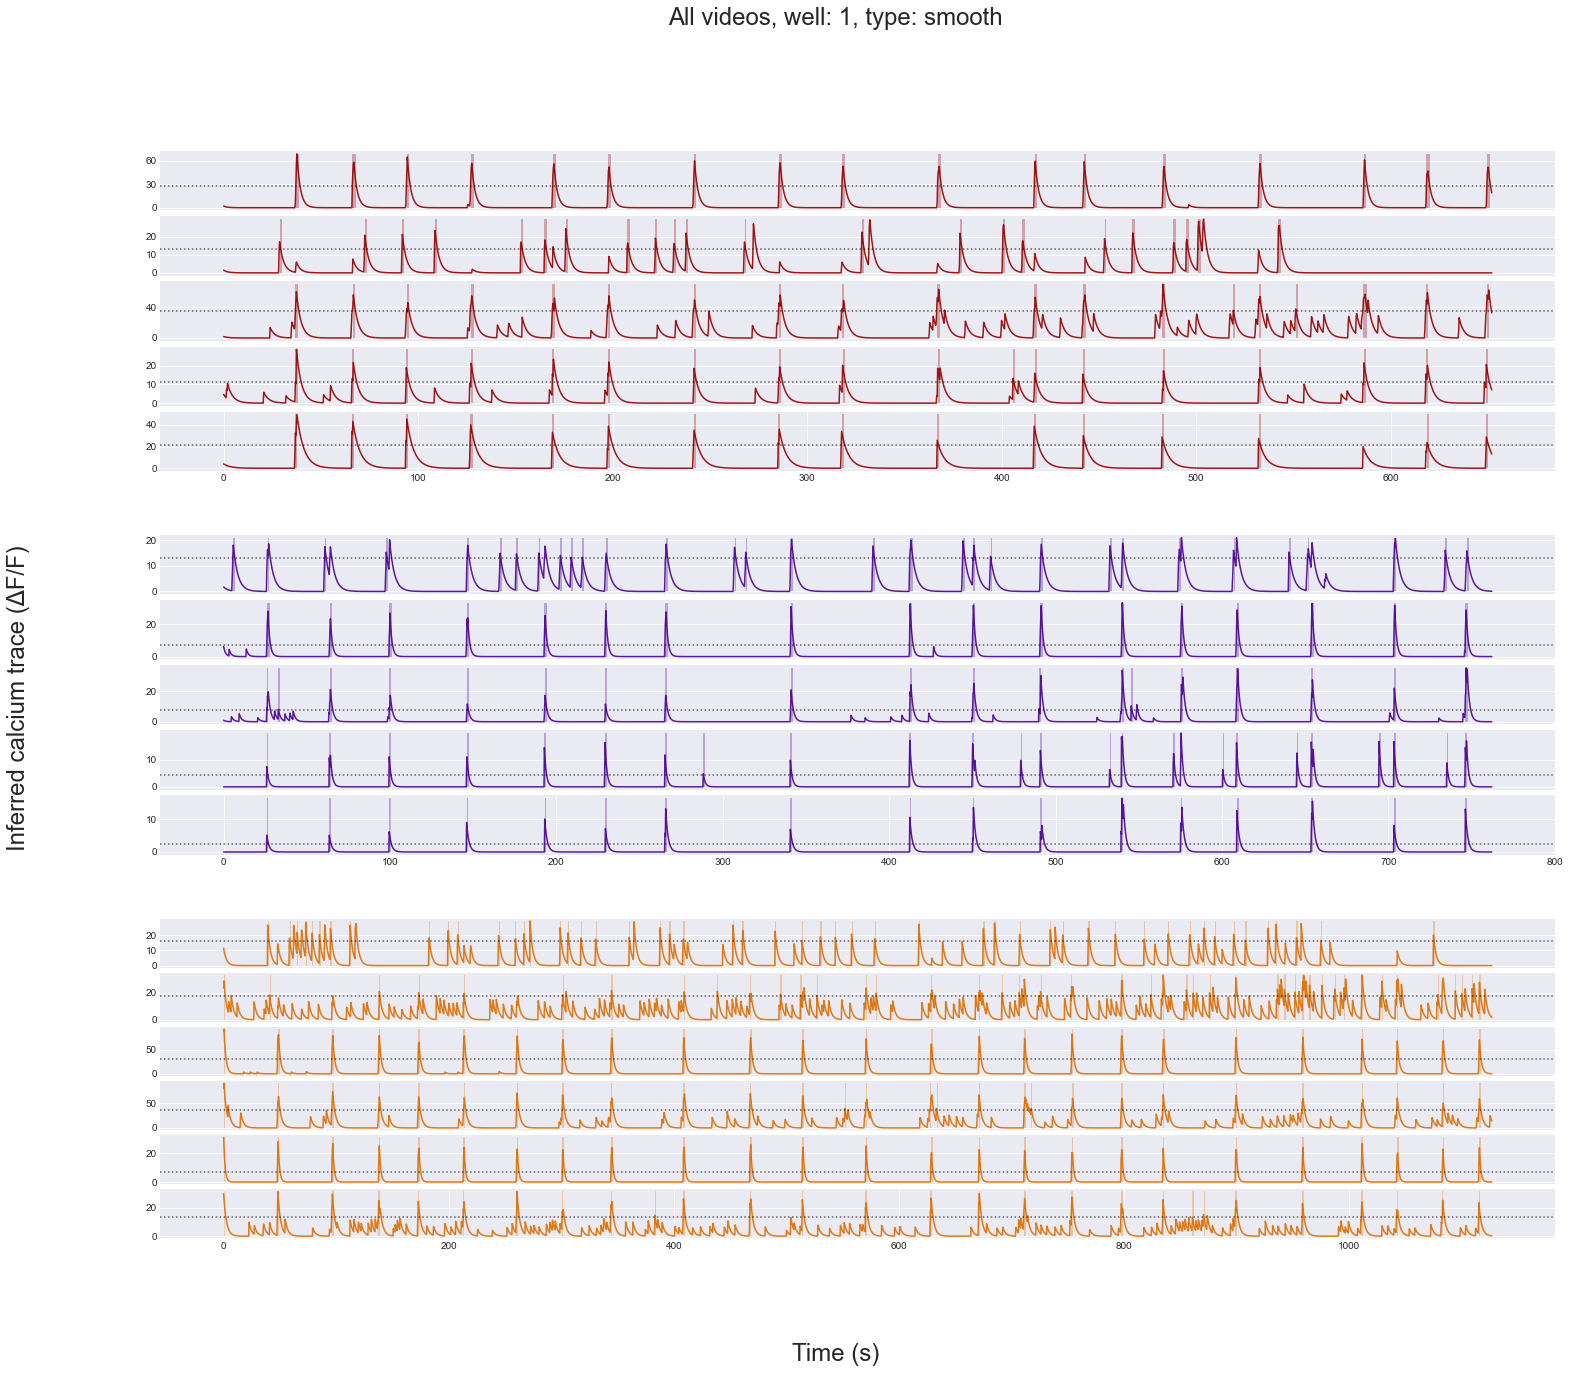

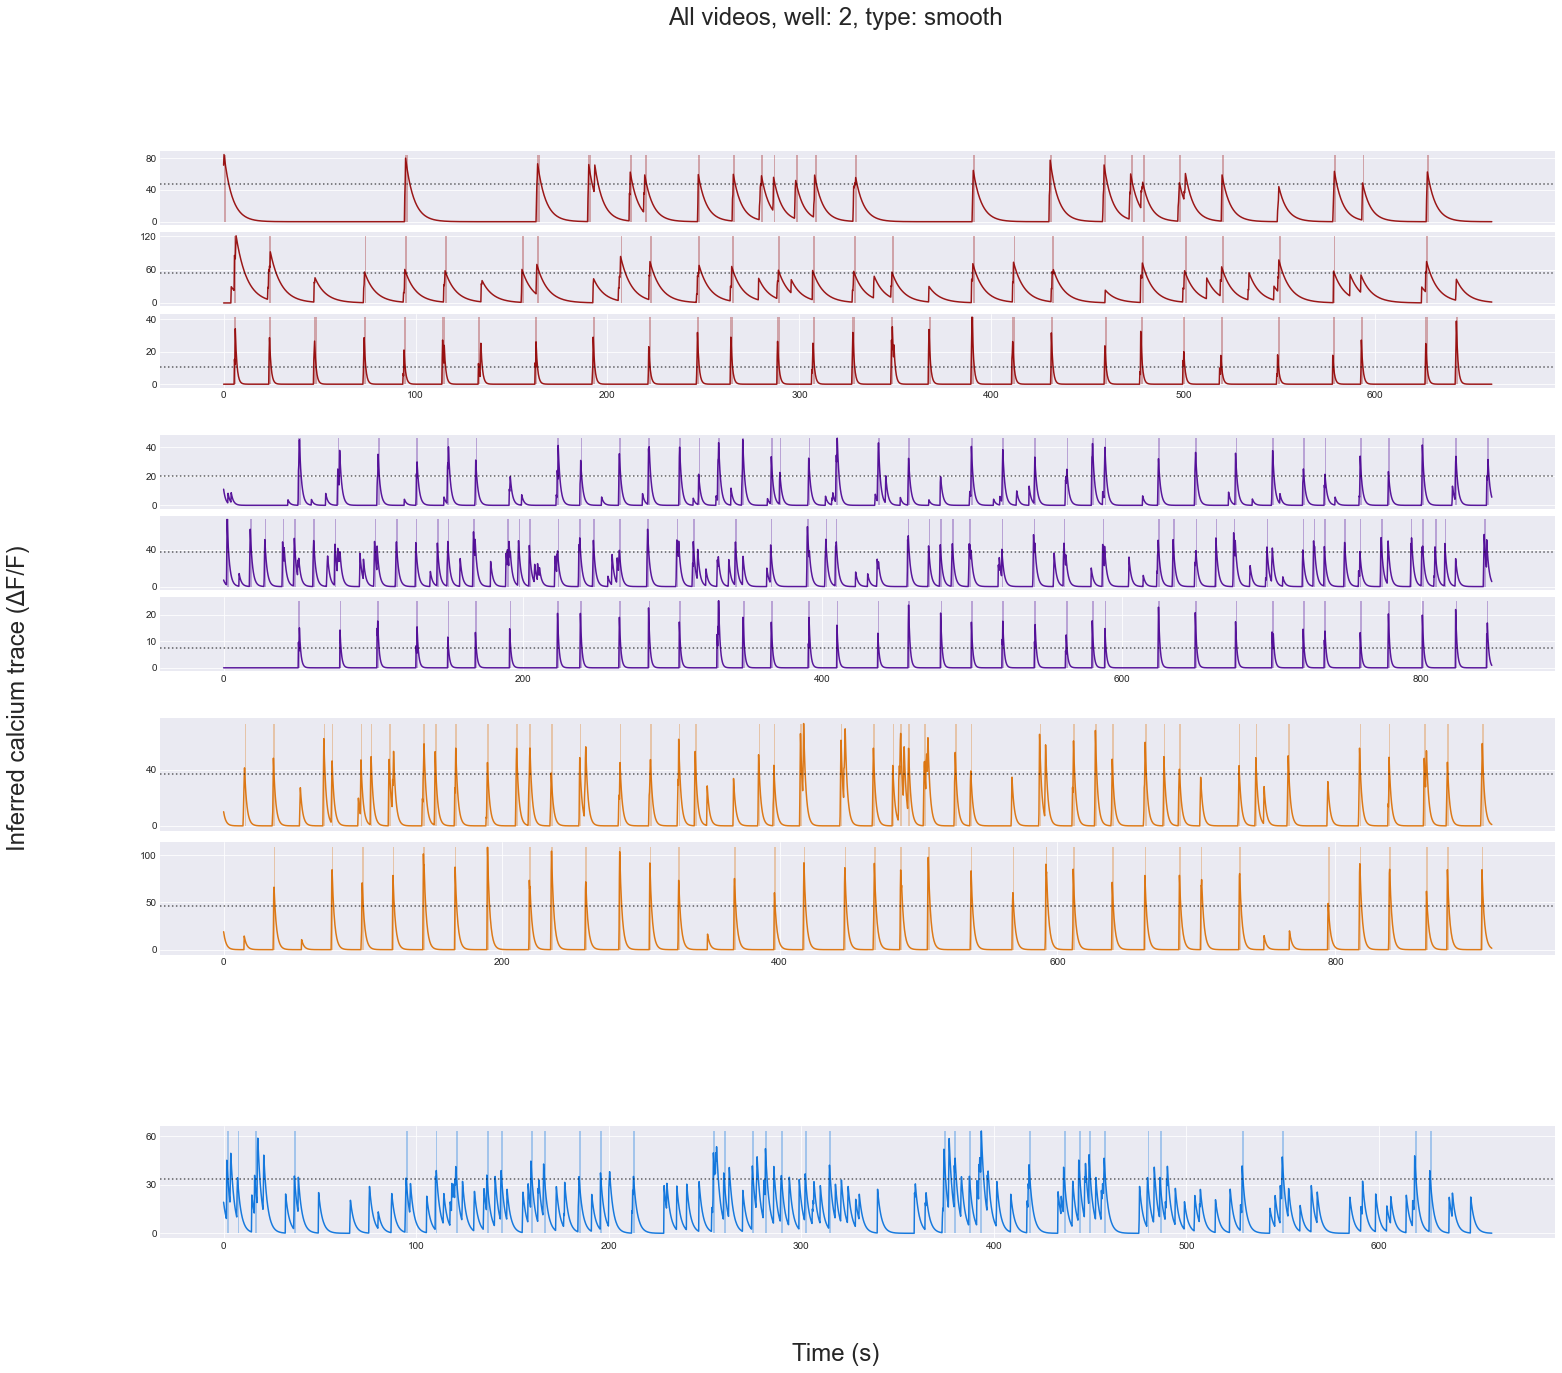

In [31]:
# df with traces/neurons as columns 

# take final column (trace) and extract it's well to get total amount of wells 
n_wells = int(df.columns[-1].split('.')[0])
data_types = ['smooth'] # DEVNOTE: for now removed 'raw'
# create separate figures for wells and raw/smooth data types 
for n in range(1, n_wells + 1):
    for type in data_types:
        # TODO reinput defaults: define_spikes = to_define_spikes, define_network_bursts = to_define_network_bursts
        # plot_traces(df = df, type = type, well = n, spikes = df_spikes, network_bursts = df_network_bursts, thresholds = df_threshold, define_spikes = True, define_network_bursts = False,                         show_equal_trace_length = show_equal_trace_length)
        plot_traces_new(df = df, type = type, well = n, spikes = df_spikes, network_bursts = df_network_bursts, thresholds = df_threshold, define_spikes = True, define_network_bursts = False,                         show_equal_trace_length = show_equal_trace_length)
        if to_plot_distributions:
            plot_distribution(df = df, type = type, well = n)


In [32]:
pd_stats = pd.concat([df_stats_spikes, df_stats_network_bursts], axis = 1)
pd_stats['network_bursts_per_minute'] = pd_stats['n_network_bursts'] / (pd_stats['seconds_measured'] / 60)
# TODO cannot have more bursts than spikes, something in calculations is going wrong! (probably in the many loops ...)
pd_stats['spike_activity_per_burst'] = pd_stats['n_spikes'] / pd_stats['n_network_bursts'] 
print(pd_stats)

pd_stats.to_excel('plots/stats.xlsx')

              n_spikes  spikes_per_minute  seconds_measured  n_network_bursts  \
1.1.1.smooth        17           1.564651         651.90255                11   
1.1.2.smooth        22           2.024843         651.90255                 0   
1.1.3.smooth        19           1.748728         651.90255                13   
1.1.4.smooth        18           1.656689         651.90255                13   
1.1.5.smooth        16           1.472613         651.90255                 7   
1.2.1.smooth        31           2.440416         762.16512                 6   
1.2.2.smooth        17           1.338293         762.16512                27   
1.2.3.smooth        19           1.495739         762.16512                24   
1.2.4.smooth        24           1.889354         762.16512                21   
1.2.5.smooth        17           1.338293         762.16512                26   
1.3.1.smooth        51           2.715177        1126.99818                 5   
1.3.2.smooth        44      